# KMeans 개선안 6: 사전 학습된 CNN 특징 사용

이 실험에서는 ImageNet 데이터셋으로 사전 학습된 거대 CNN 모델인 **VGG16**을 특징 추출기(Feature Extractor)로 사용하여 이미지의 고차원 윤곽선, 질감, 시각적 의미(Semantics) 정보를 요약한 특징 벡터를 추출합니다. 이후 추출된 특징 벡터를 사용하여 KMeans 군집화를 수행하고 기존 방식들과 성능을 비교합니다.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

# 1. 데이터 로드 및 확인
data_path = Path('fruits_300.npy')
if not data_path.exists():
    urlretrieve('https://bit.ly/fruits_300_data', data_path)

fruits = np.load('fruits_300.npy')
print('fruits shape:', fruits.shape)  # (300, 100, 100)

fruits shape: (300, 100, 100)


In [2]:
# 2. CNN 전처리를 위한 이미지 가공
# VGG16은 3채널 RGB 이미지를 입력으로 받으므로, 1채널 흑백 이미지를 3채널로 반복 확장합니다.
fruits_rgb = np.repeat(fruits[..., np.newaxis], 3, axis=-1)  # (300, 100, 100, 3)

# VGG16의 정규화 전처리 적용 (입력 범위 및 채널 전환)
# VGG16은 0~255 범위의 입력을 예상하므로 정수 이미지 데이터를 입력합니다.
fruits_preprocessed = preprocess_input(fruits_rgb * 255.0)
print('Preprocessed input shape:', fruits_preprocessed.shape)

Preprocessed input shape: (300, 100, 100, 3)


In [3]:
# 3. 사전 학습된 VGG16 특징 추출기 로드
# include_top=False로 설정하여 최상단 분류층을 제외하고 합성곱 층들만 가져옵니다.
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(100, 100, 3))

# 이미지로부터 특징 맵 추출
features = base_model.predict(fruits_preprocessed)
print('Extracted feature map shape:', features.shape)  # (300, 3, 3, 512)

# 3x3x512 특징 맵을 1차원 벡터로 평평하게 만듭니다. (300, 4608차원)
features_flatten = features.reshape(features.shape[0], -1)
print('Flattened feature shape:', features_flatten.shape)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 253ms/step
Extracted feature map shape: (300, 3, 3, 512)
Flattened feature shape: (300, 4608)


In [4]:
# 4. 특징 벡터 표준화
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_flatten)

In [5]:
# 5. 최적의 K 탐색 (엘보우 및 다양한 평가지표 확인)
scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(features_scaled)
    
    score = silhouette_score(features_scaled, labels)
    db_score = davies_bouldin_score(features_scaled, labels)
    ch_score = calinski_harabasz_score(features_scaled, labels)
    
    scores.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': score,
        'davies_bouldin': db_score,
        'calinski_harabasz': ch_score
    })
    print(f'k={k} | Inertia={km.inertia_:.2f} | Silhouette={score:.3f} | Davies-Bouldin={db_score:.3f}')

k=2 | Inertia=908248.81 | Silhouette=0.086 | Davies-Bouldin=2.695
k=3 | Inertia=850534.62 | Silhouette=0.078 | Davies-Bouldin=2.910
k=4 | Inertia=815226.12 | Silhouette=0.115 | Davies-Bouldin=2.452
k=5 | Inertia=767586.88 | Silhouette=0.105 | Davies-Bouldin=2.464
k=6 | Inertia=742422.88 | Silhouette=0.111 | Davies-Bouldin=2.292
k=7 | Inertia=712475.94 | Silhouette=0.130 | Davies-Bouldin=2.081
k=8 | Inertia=699373.75 | Silhouette=0.056 | Davies-Bouldin=2.325
k=9 | Inertia=682027.81 | Silhouette=0.122 | Davies-Bouldin=2.306
k=10 | Inertia=657531.25 | Silhouette=0.074 | Davies-Bouldin=2.288


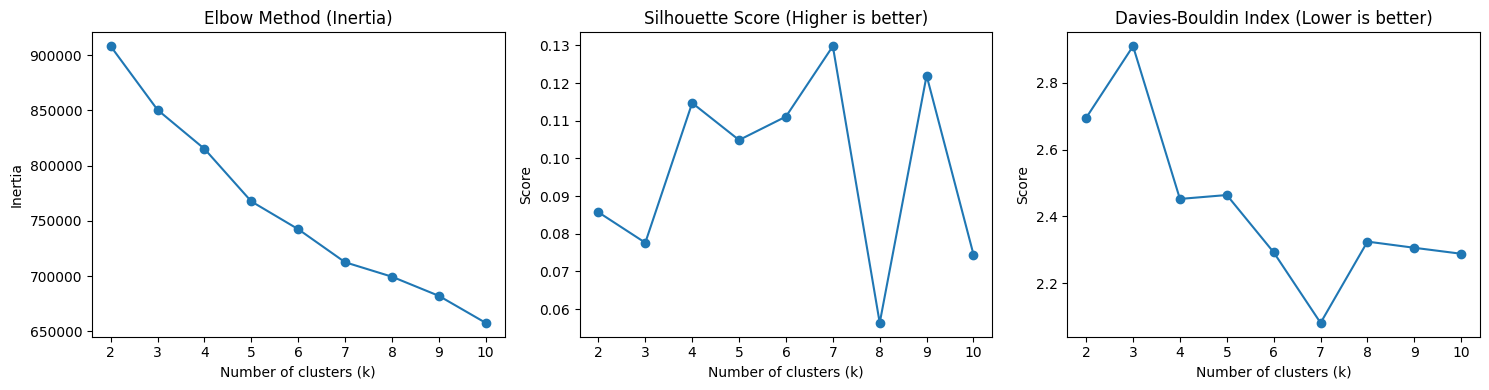

In [6]:
# 6. 평가지표 시각화
ks = [s['k'] for s in scores]
inertias = [s['inertia'] for s in scores]
silhouettes = [s['silhouette'] for s in scores]
db_scores = [s['davies_bouldin'] for s in scores]

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(ks, inertias, 'o-')
axs[0].set_title('Elbow Method (Inertia)')
axs[0].set_xlabel('Number of clusters (k)')
axs[0].set_ylabel('Inertia')

axs[1].plot(ks, silhouettes, 'o-')
axs[1].set_title('Silhouette Score (Higher is better)')
axs[1].set_xlabel('Number of clusters (k)')
axs[1].set_ylabel('Score')

axs[2].plot(ks, db_scores, 'o-')
axs[2].set_title('Davies-Bouldin Index (Lower is better)')
axs[2].set_xlabel('Number of clusters (k)')
axs[2].set_ylabel('Score')

plt.tight_layout()
plt.show()

In [7]:
# 7. 최적의 K=3으로 군집화 수행
km = KMeans(n_clusters=3, n_init=20, random_state=42)
labels = km.fit_predict(features_scaled)

print('Labels distribution:', np.unique(labels, return_counts=True))
print('Final Silhouette Score:', silhouette_score(features_scaled, labels))
print('Final Davies-Bouldin Score:', davies_bouldin_score(features_scaled, labels))

Labels distribution: (array([0, 1, 2], dtype=int32), array([102,  98, 100]))
Final Silhouette Score: 0.077601545
Final Davies-Bouldin Score: 2.910159497341933


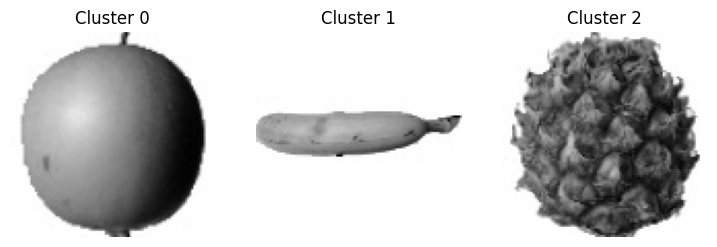

In [8]:
# 8. 각 군집별 대표 샘플 시각화
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
for cluster_id, ax in enumerate(axs):
    # 해당 군집의 첫 번째 과일 인덱스 탐색
    sample_index = np.where(labels == cluster_id)[0][0]
    ax.imshow(fruits[sample_index], cmap='gray_r')
    ax.set_title(f'Cluster {cluster_id}')
    ax.axis('off')
plt.show()